# Lab 2: DCGAN and WGAN-GP on FashionMNIST

## 1. Install Dependencies

In [6]:
%pip -q install tqdm matplotlib pandas pillow

## 2. Imports and Configuration

In [7]:
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import autograd, nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image


@dataclass
class Config:
    seed: int = 42
    model_seed: int = 123
    fixed_z_seed: int = 2026
    final_z_seed: int = 9090
    dataset_name: str = 'FashionMNIST'
    data_dir: str = '/content/data'
    run_dir: str = '/content/lab2_fashionmnist_gan_runs'
    image_size: int = 28
    channels: int = 1
    latent_dim: int = 100
    batch_size: int = 128
    num_workers: int = 2
    gan_steps: int = 10000
    snapshot_steps: tuple = (0, 1000, 3000, 5000, 10000)
    dcgan_lr: float = 2e-4
    dcgan_betas: tuple = (0.5, 0.999)
    wgan_lr: float = 1e-4
    wgan_betas: tuple = (0.0, 0.9)
    n_critic: int = 5
    lambda_gp: float = 10.0
    grid_nrow: int = 8


cfg = Config()
RUN_DIR = Path(cfg.run_dir)
ASSET_DIR = RUN_DIR / 'assets'
ASSET_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(cfg.seed)
torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

hyperparameters = pd.DataFrame([
    ('Dataset', cfg.dataset_name),
    ('Image size', f'{cfg.channels} x {cfg.image_size} x {cfg.image_size}'),
    ('Image normalization', '[-1, 1]'),
    ('Latent dimension', cfg.latent_dim),
    ('Batch size', cfg.batch_size),
    ('Generator updates', cfg.gan_steps),
    ('Snapshot steps', str(cfg.snapshot_steps)),
    ('Vanilla GAN optimizer', f'Adam, lr={cfg.dcgan_lr}, betas={cfg.dcgan_betas}'),
    ('WGAN-GP optimizer', f'Adam, lr={cfg.wgan_lr}, betas={cfg.wgan_betas}'),
    ('WGAN-GP critic updates', cfg.n_critic),
    ('Gradient penalty lambda', cfg.lambda_gp),
    ('Training dtype', 'float32'),
], columns=['Item', 'Value'])
hyperparameters

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


,Item,Value
0,Dataset,FashionMNIST
1,Image size,1 x 28 x 28
2,Image normalization,"[-1, 1]"
3,Latent dimension,100
4,Batch size,128
5,Generator updates,10000
6,Snapshot steps,"(0, 1000, 3000, 5000, 10000)"
7,Vanilla GAN optimizer,"Adam, lr=0.0002, betas=(0.5, 0.999)"
8,WGAN-GP optimizer,"Adam, lr=0.0001, betas=(0.0, 0.9)"
9,WGAN-GP critic updates,5


## 3. Dataset and Infinite Dataloader

In [8]:
def seed_worker(worker_id: int) -> None:
    worker_seed = cfg.seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.FashionMNIST(
    root=cfg.data_dir,
    train=True,
    download=True,
    transform=transform,
)


def make_train_loader(seed: int) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=cfg.num_workers,
        pin_memory=(device.type == 'cuda'),
        worker_init_fn=seed_worker,
        generator=generator,
    )


def infinite_dataloader(loader: DataLoader):
    while True:
        for batch in loader:
            yield batch


preview_loader = make_train_loader(cfg.seed)
preview_images, preview_labels = next(iter(preview_loader))
print('One batch shape:', tuple(preview_images.shape))
print('Pixel range after normalization:', float(preview_images.min()), float(preview_images.max()))

One batch shape: (128, 1, 28, 28)
Pixel range after normalization: -1.0 1.0


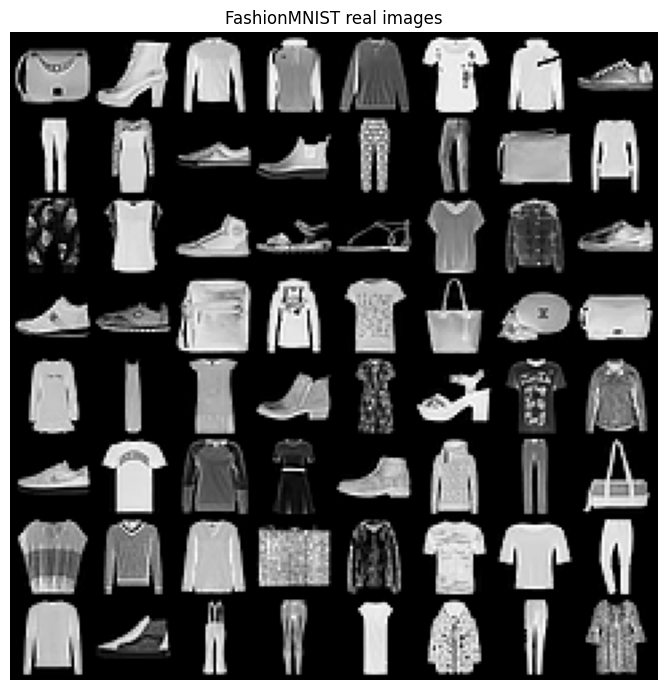

In [9]:
def denormalize(images: torch.Tensor) -> torch.Tensor:
    return ((images.detach().cpu() + 1.0) / 2.0).clamp(0.0, 1.0)


preview_grid = make_grid(denormalize(preview_images[:64]), nrow=8, padding=2)
plt.figure(figsize=(7, 7))
plt.imshow(np.transpose(preview_grid.numpy(), (1, 2, 0)), cmap='gray')
plt.title('FashionMNIST real images')
plt.axis('off')
plt.tight_layout()
plt.savefig(ASSET_DIR / 'fashionmnist_real_preview.png', dpi=160)
plt.show()

## 5. Model Definitions

In [11]:
class Generator(nn.Module):
    def __init__(self, latent_dim: int = 100):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),
        )
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.project(z)
        x = x.view(z.size(0), 128, 7, 7)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LayerNorm([128, 7, 7]),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def dcgan_weights_init(module: nn.Module) -> None:
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.0)
    elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.LayerNorm)):
        if module.weight is not None:
            nn.init.normal_(module.weight, mean=1.0, std=0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.0)


def build_vanilla_models():
    torch.manual_seed(cfg.model_seed)
    generator = Generator(cfg.latent_dim).to(device)
    generator.apply(dcgan_weights_init)

    torch.manual_seed(cfg.model_seed + 1)
    discriminator = Discriminator().to(device)
    discriminator.apply(dcgan_weights_init)
    return generator, discriminator


def build_wgan_models():
    torch.manual_seed(cfg.model_seed)
    generator = Generator(cfg.latent_dim).to(device)
    generator.apply(dcgan_weights_init)

    torch.manual_seed(cfg.model_seed + 2)
    critic = Critic().to(device)
    critic.apply(dcgan_weights_init)
    return generator, critic

In [12]:
test_G, test_D = build_vanilla_models()
test_G_wgan, test_C = build_wgan_models()

z_test = torch.randn(4, cfg.latent_dim, device=device)
x_test = torch.randn(4, 1, 28, 28, device=device)

with torch.no_grad():
    fake_test = test_G(z_test)
    d_test = test_D(x_test)
    c_test = test_C(x_test)
    fake_wgan_test = test_G_wgan(z_test)

assert fake_test.shape == (4, 1, 28, 28)
assert d_test.shape == (4, 1)
assert c_test.shape == (4, 1)
assert torch.allclose(fake_test.cpu(), fake_wgan_test.cpu())

print('Generator output:', tuple(fake_test.shape))
print('Discriminator output:', tuple(d_test.shape))
print('Critic output:', tuple(c_test.shape))
print('Both experiments start from the same generator weights:', torch.allclose(fake_test.cpu(), fake_wgan_test.cpu()))

del test_G, test_D, test_G_wgan, test_C, z_test, x_test, fake_test, d_test, c_test, fake_wgan_test
torch.cuda.empty_cache()

Generator output: (4, 1, 28, 28)
Discriminator output: (4, 1)
Critic output: (4, 1)
Both experiments start from the same generator weights: True


## 6. Fixed Latent Batch and Plot Helpers

In [13]:
def sample_noise(batch_size: int, seed: int | None = None) -> torch.Tensor:
    if seed is None:
        return torch.randn(batch_size, cfg.latent_dim, device=device, dtype=torch.float32)
    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)
    z = torch.randn(batch_size, cfg.latent_dim, generator=generator, dtype=torch.float32)
    return z.to(device)


z_fixed = sample_noise(64, cfg.fixed_z_seed)
print('Fixed z shape:', tuple(z_fixed.shape))


def save_generator_grid(generator: nn.Module, z: torch.Tensor, out_path: Path) -> str:
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        images = generator(z)
    if was_training:
        generator.train()
    save_image(denormalize(images), out_path, nrow=cfg.grid_nrow, padding=2)
    return str(out_path)


def show_saved_image(path: str | Path, title: str | None = None) -> None:
    image = Image.open(path).convert('RGB')
    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def smooth(values, window: int = 100) -> pd.Series:
    return pd.Series(values).rolling(window=window, min_periods=1).mean()

Fixed z shape: (64, 100)


## 7. Part A: Vanilla DCGAN

In [14]:
def train_dcgan(z_fixed: torch.Tensor):
    generator, discriminator = build_vanilla_models()
    train_iter = infinite_dataloader(make_train_loader(cfg.seed))

    criterion = nn.BCELoss()
    opt_G = optim.Adam(generator.parameters(), lr=cfg.dcgan_lr, betas=cfg.dcgan_betas)
    opt_D = optim.Adam(discriminator.parameters(), lr=cfg.dcgan_lr, betas=cfg.dcgan_betas)

    snapshot_dir = ASSET_DIR / 'dcgan_snapshots'
    snapshot_dir.mkdir(parents=True, exist_ok=True)
    snapshots = {
        0: save_generator_grid(generator, z_fixed, snapshot_dir / 'dcgan_step_00000.png')
    }

    logs = []
    progress = tqdm(range(1, cfg.gan_steps + 1), desc='Vanilla DCGAN')

    for step in progress:
        real_images, _ = next(train_iter)
        real_images = real_images.to(device, dtype=torch.float32, non_blocking=True)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device, dtype=torch.float32)
        fake_labels = torch.zeros(batch_size, 1, device=device, dtype=torch.float32)

        discriminator.zero_grad(set_to_none=True)
        real_pred = discriminator(real_images)
        real_loss = criterion(real_pred, real_labels)

        z = sample_noise(batch_size)
        fake_images = generator(z).detach()
        fake_pred = discriminator(fake_images)
        fake_loss = criterion(fake_pred, fake_labels)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        opt_D.step()

        generator.zero_grad(set_to_none=True)
        z = sample_noise(batch_size)
        fake_images = generator(z)
        fake_pred = discriminator(fake_images)
        g_loss = criterion(fake_pred, real_labels)
        g_loss.backward()
        opt_G.step()

        logs.append({
            'step': step,
            'd_loss': float(d_loss.item()),
            'g_loss': float(g_loss.item()),
        })

        if step in cfg.snapshot_steps:
            snapshots[step] = save_generator_grid(
                generator,
                z_fixed,
                snapshot_dir / f'dcgan_step_{step:05d}.png',
            )

        if step % 100 == 0:
            progress.set_postfix(d_loss=f'{d_loss.item():.3f}', g_loss=f'{g_loss.item():.3f}')

    log_df = pd.DataFrame(logs)
    log_df.to_csv(ASSET_DIR / 'dcgan_losses.csv', index=False)
    torch.save(generator.state_dict(), RUN_DIR / 'dcgan_generator.pt')
    torch.save(discriminator.state_dict(), RUN_DIR / 'dcgan_discriminator.pt')
    return generator, discriminator, log_df, snapshots

## 8. Part B: WGAN-GP

In [15]:
def gradient_penalty(critic: nn.Module, real_images: torch.Tensor, fake_images: torch.Tensor):
    batch_size = real_images.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device, dtype=torch.float32)
    x_hat = epsilon * real_images + (1.0 - epsilon) * fake_images
    x_hat.requires_grad_(True)

    scores = critic(x_hat)
    grad_outputs = torch.ones_like(scores, device=device)
    gradients = autograd.grad(
        outputs=scores,
        inputs=x_hat,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    penalty = cfg.lambda_gp * ((gradient_norm - 1.0) ** 2).mean()
    return penalty, gradient_norm.detach()


def train_wgan_gp(z_fixed: torch.Tensor):
    generator, critic = build_wgan_models()
    train_iter = infinite_dataloader(make_train_loader(cfg.seed))

    opt_G = optim.Adam(generator.parameters(), lr=cfg.wgan_lr, betas=cfg.wgan_betas)
    opt_C = optim.Adam(critic.parameters(), lr=cfg.wgan_lr, betas=cfg.wgan_betas)

    snapshot_dir = ASSET_DIR / 'wgan_gp_snapshots'
    snapshot_dir.mkdir(parents=True, exist_ok=True)
    snapshots = {
        0: save_generator_grid(generator, z_fixed, snapshot_dir / 'wgan_gp_step_00000.png')
    }

    logs = []
    progress = tqdm(range(1, cfg.gan_steps + 1), desc='WGAN-GP')

    for step in progress:
        w_values = []
        gp_values = []
        c_loss_values = []

        for _ in range(cfg.n_critic):
            real_images, _ = next(train_iter)
            real_images = real_images.to(device, dtype=torch.float32, non_blocking=True)
            batch_size = real_images.size(0)

            with torch.no_grad():
                z = sample_noise(batch_size)
                fake_images = generator(z)

            critic.zero_grad(set_to_none=True)
            real_scores = critic(real_images)
            fake_scores = critic(fake_images)
            gp, grad_norm = gradient_penalty(critic, real_images, fake_images)

            c_loss = fake_scores.mean() - real_scores.mean() + gp
            c_loss.backward()
            opt_C.step()

            w_estimate = real_scores.mean() - fake_scores.mean()
            w_values.append(float(w_estimate.item()))
            gp_values.append(float(gp.item()))
            c_loss_values.append(float(c_loss.item()))

        generator.zero_grad(set_to_none=True)
        z = sample_noise(cfg.batch_size)
        fake_images = generator(z)
        g_loss = -critic(fake_images).mean()
        g_loss.backward()
        opt_G.step()

        logs.append({
            'step': step,
            'w_estimate': float(np.mean(w_values)),
            'gradient_penalty': float(np.mean(gp_values)),
            'critic_loss': float(np.mean(c_loss_values)),
            'g_loss': float(g_loss.item()),
        })

        if step in cfg.snapshot_steps:
            snapshots[step] = save_generator_grid(
                generator,
                z_fixed,
                snapshot_dir / f'wgan_gp_step_{step:05d}.png',
            )

        if step % 100 == 0:
            progress.set_postfix(w_hat=f'{np.mean(w_values):.3f}', gp=f'{np.mean(gp_values):.3f}', g_loss=f'{g_loss.item():.3f}')

    log_df = pd.DataFrame(logs)
    log_df.to_csv(ASSET_DIR / 'wgan_gp_losses.csv', index=False)
    torch.save(generator.state_dict(), RUN_DIR / 'wgan_gp_generator.pt')
    torch.save(critic.state_dict(), RUN_DIR / 'wgan_gp_critic.pt')
    return generator, critic, log_df, snapshots

## 9. Train Both Models

In [ ]:
start_time = time.time()

dcgan_G, dcgan_D, dcgan_log, dcgan_snapshots = train_dcgan(z_fixed)
wgan_G, wgan_C, wgan_log, wgan_snapshots = train_wgan_gp(z_fixed)

elapsed_min = (time.time() - start_time) / 60.0
print(f'Training finished in {elapsed_min:.1f} minutes')
print('Saved files in:', RUN_DIR)

Vanilla DCGAN:   0%|          | 0/10000 [00:00<?, ?it/s]

WGAN-GP:   0%|          | 0/10000 [00:00<?, ?it/s]

Training finished in 13.9 minutes
Saved files in: /content/lab2_fashionmnist_gan_runs


## 10. Figure 1: Loss Curves

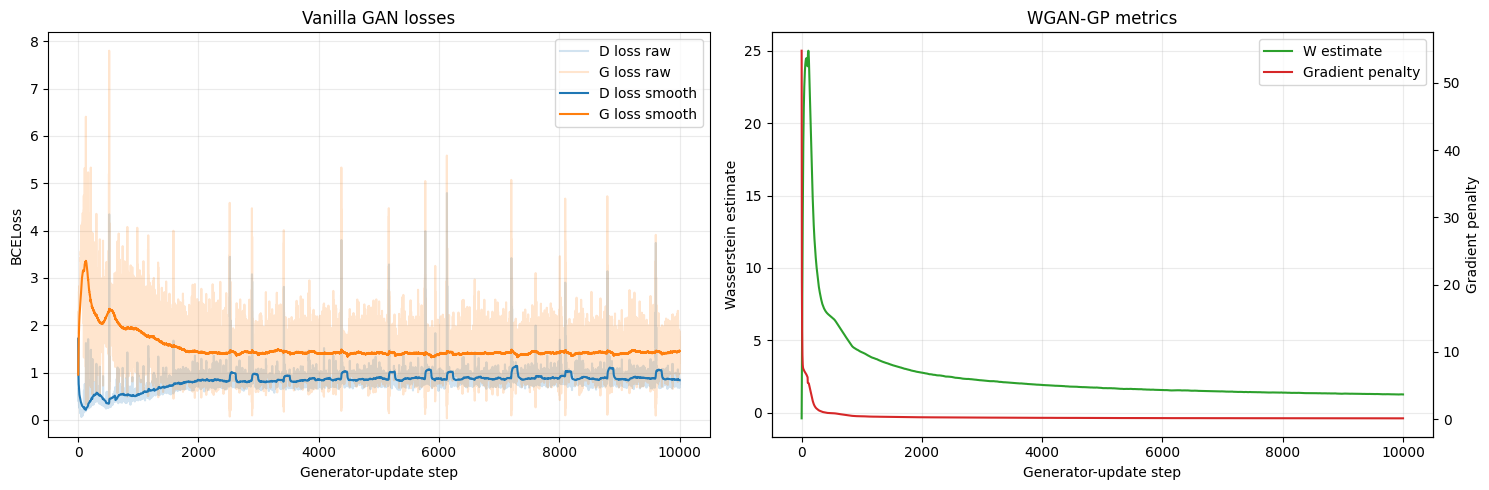

In [17]:
def plot_loss_curves(dcgan_log: pd.DataFrame, wgan_log: pd.DataFrame, out_path: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    ax.plot(dcgan_log['step'], dcgan_log['d_loss'], alpha=0.20, color='#1f77b4', label='D loss raw')
    ax.plot(dcgan_log['step'], dcgan_log['g_loss'], alpha=0.20, color='#ff7f0e', label='G loss raw')
    ax.plot(dcgan_log['step'], smooth(dcgan_log['d_loss']), color='#1f77b4', label='D loss smooth')
    ax.plot(dcgan_log['step'], smooth(dcgan_log['g_loss']), color='#ff7f0e', label='G loss smooth')
    ax.set_title('Vanilla GAN losses')
    ax.set_xlabel('Generator-update step')
    ax.set_ylabel('BCELoss')
    ax.grid(alpha=0.25)
    ax.legend()

    ax1 = axes[1]
    ax2 = ax1.twinx()
    line1 = ax1.plot(wgan_log['step'], smooth(wgan_log['w_estimate']), color='#2ca02c', label='W estimate')
    line2 = ax2.plot(wgan_log['step'], smooth(wgan_log['gradient_penalty']), color='#d62728', label='Gradient penalty')
    ax1.set_title('WGAN-GP metrics')
    ax1.set_xlabel('Generator-update step')
    ax1.set_ylabel('Wasserstein estimate')
    ax2.set_ylabel('Gradient penalty')
    ax1.grid(alpha=0.25)
    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='best')

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()


plot_loss_curves(dcgan_log, wgan_log, ASSET_DIR / 'figure_1_loss_curves.png')

## 11. Figure 2: Sample Grid Evolution


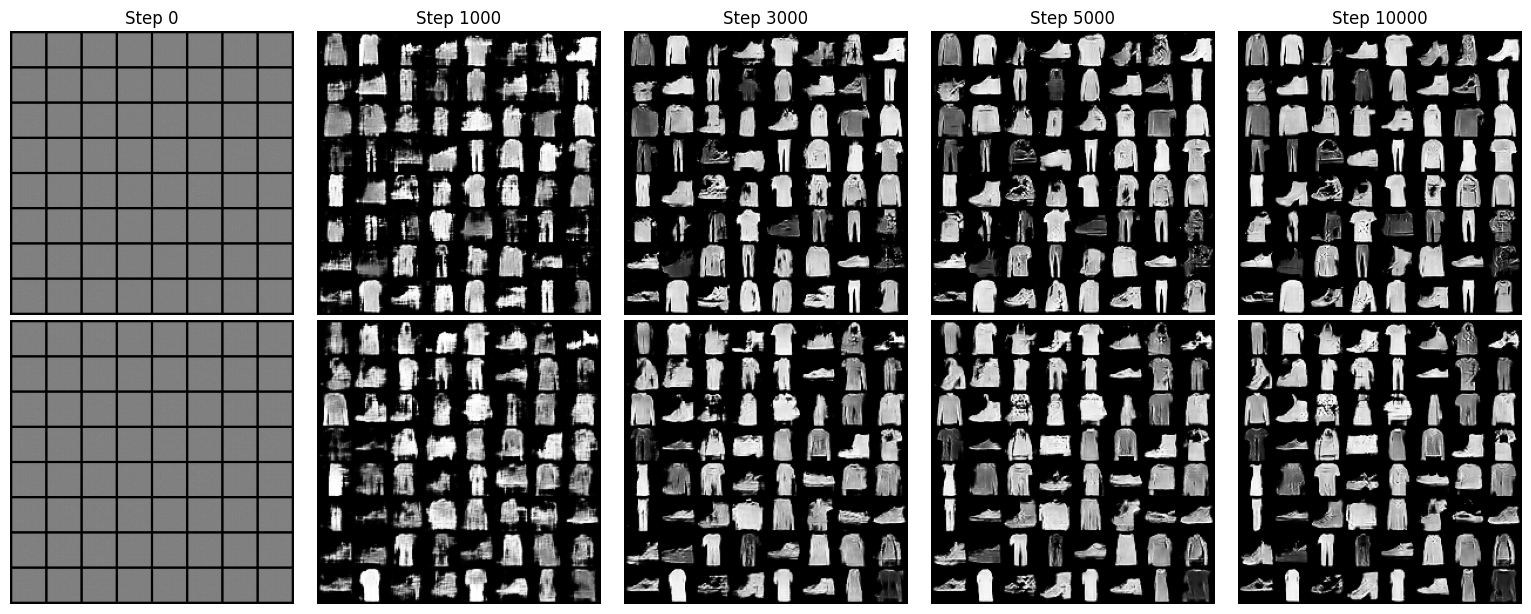

In [18]:
def plot_sample_evolution(dcgan_snapshots: dict, wgan_snapshots: dict, out_path: Path) -> None:
    steps = list(cfg.snapshot_steps)
    fig, axes = plt.subplots(2, len(steps), figsize=(3.1 * len(steps), 6.2))

    for col, step in enumerate(steps):
        dcgan_image = Image.open(dcgan_snapshots[step]).convert('RGB')
        wgan_image = Image.open(wgan_snapshots[step]).convert('RGB')

        axes[0, col].imshow(dcgan_image)
        axes[0, col].set_title(f'Step {step}')
        axes[0, col].axis('off')

        axes[1, col].imshow(wgan_image)
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('Vanilla GAN', fontsize=12)
    axes[1, 0].set_ylabel('WGAN-GP', fontsize=12)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()


plot_sample_evolution(dcgan_snapshots, wgan_snapshots, ASSET_DIR / 'figure_2_sample_evolution.png')

## 12. Figure 3: Sampling from N(0, I)

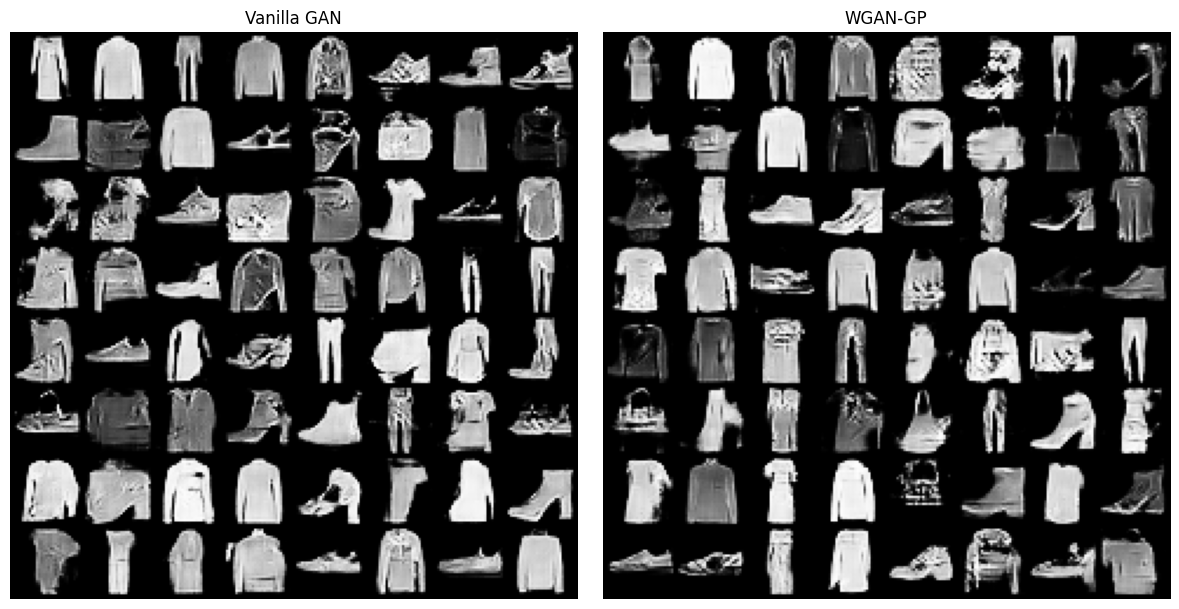

In [19]:
def plot_final_samples(dcgan_G: nn.Module, wgan_G: nn.Module, out_path: Path) -> None:
    z_final = sample_noise(64, cfg.final_z_seed)

    dcgan_G.eval()
    wgan_G.eval()
    with torch.no_grad():
        dcgan_images = dcgan_G(z_final)
        wgan_images = wgan_G(z_final)

    dcgan_grid = make_grid(denormalize(dcgan_images), nrow=8, padding=2)
    wgan_grid = make_grid(denormalize(wgan_images), nrow=8, padding=2)

    save_image(denormalize(dcgan_images), ASSET_DIR / 'dcgan_final_samples.png', nrow=8, padding=2)
    save_image(denormalize(wgan_images), ASSET_DIR / 'wgan_gp_final_samples.png', nrow=8, padding=2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(np.transpose(dcgan_grid.numpy(), (1, 2, 0)))
    axes[0].set_title('Vanilla GAN')
    axes[0].axis('off')

    axes[1].imshow(np.transpose(wgan_grid.numpy(), (1, 2, 0)))
    axes[1].set_title('WGAN-GP')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()


plot_final_samples(dcgan_G, wgan_G, ASSET_DIR / 'figure_3_final_samples.png')

## 13. Final Metric Summary

In [ ]:
summary = pd.DataFrame([
    {
        'model': 'Vanilla GAN',
        'final_d_loss': dcgan_log['d_loss'].iloc[-1],
        'final_g_loss': dcgan_log['g_loss'].iloc[-1],
        'final_w_estimate': np.nan,
        'final_gradient_penalty': np.nan,
    },
    {
        'model': 'WGAN-GP',
        'final_d_loss': np.nan,
        'final_g_loss': wgan_log['g_loss'].iloc[-1],
        'final_w_estimate': wgan_log['w_estimate'].iloc[-1],
        'final_gradient_penalty': wgan_log['gradient_penalty'].iloc[-1],
    },
])
summary.to_csv(ASSET_DIR / 'final_metric_summary.csv', index=False)
summary

,model,final_d_loss,final_g_loss,final_w_estimate,final_gradient_penalty
0,Vanilla GAN,0.809276,1.214231,NaN,NaN
1,WGAN-GP,NaN,30.732437,1.288663,0.119379
